# Summer project code

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

from scipy.stats import norm
from scipy.special import expit
from scipy.interpolate import interp1d

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, TunedThresholdClassifierCV
from sklearn.datasets import make_classification
from sklearn.base import BaseEstimator
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
import torch


## Preliminary 

### Synthetic data generation

In [2]:
def generate_dataset(n_samples=10000, n_features=10, p=0.1, random_state=0):
    """
    Generates a binary classification dataset where y depends on X.
    The positive class has proportion ~p.

    Parameters:
        n_samples (int): number of samples in the dataset 
        n_features (int): number of features in the dataset 
        p (float): proportion of positive samples in the dataset, 0<p<1
        seed (int): generator seed

     Returns:
        np.array: generated design matrix
        np.arry: generated target variable
    """

    # Generate X
    rng = np.random.default_rng(random_state)  
    X = rng.standard_normal((n_samples, n_features))

    #X = np.random.randn(n_samples, n_features, random_state=random_state)

    # Define a true underlying linear model
    #weights = np.random.randn(n_features, random_state=random_state)
    weights = rng.standard_normal(n_features)
    logits = X @ weights

    # Shift threshold to control positive rate
    threshold = np.percentile(logits, 100 * (1 - p))
    y = (logits >= threshold).astype(int)

    return X, y

In [3]:
def cross_val_set(X, y, mode="train_test", test_size=0.2, val_size=None, n_splits=5, random_state=0):
    """
    Create train/test splits using either simple train_test or stratified k-fold.

    Parameters:
        X (np.array): design matrix 
        y (np.array): target variable
        mode (str): 'train_test' or 'kfold'
        test_size (float): used if mode='train_test'
        n_splits (int): used if mode='kfold'
        random_state (int): for reproducibility

    Returns:
        - If mode='train_test' and val_size:
            X_train, X_val, X_test, y_train, y_val, y_test
        - If mode='train_test':
            X_train, X_test, y_train, y_test
        - If mode='kfold':
            List of (X_train, X_test, y_train, y_test)
    """

    if mode == "train_test":
        
        if val_size:
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                random_state=random_state
            )
            val_relative = val_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp,
                test_size=val_relative,
                stratify=y_temp,
                random_state=random_state
            )
            return X_train, X_val, X_test, y_train, y_val, y_test

        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                shuffle=True,
                random_state=0
            )
            return X_train, X_test, y_train, y_test

    elif mode == "kfold":
        skf = StratifiedKFold(
            n_splits=n_splits, 
            shuffle=True, 
            random_state=0)
        folds = [
            (X[train_idx], X[test_idx], y[train_idx], y[test_idx])
            for train_idx, test_idx in skf.split(X, y)
        ]
        return folds
    
    else:
        raise ValueError("mode should be 'train_test' or 'kfold'")

In [4]:
X_01, y_01 = generate_dataset()
X_train_01, X_test_01, y_train_01, y_test_01 = cross_val_set(X_01, y_01)

In [5]:
print(np.mean(y_01))
print(np.mean(y_train_01))
print(np.mean(y_test_01))

0.1
0.1
0.1


In [6]:
X_05, y_05 = generate_dataset(p=0.5)
X_train_05, X_test_05, y_train_05, y_test_05 = cross_val_set(X_05, y_05)

X_005, y_005 = generate_dataset(p=0.05)
X_train_005, X_test_005, y_train_005, y_test_005 = cross_val_set(X_005, y_005)

X_002, y_002 = generate_dataset(p=0.02)
X_train_002, X_test_002, y_train_002, y_test_002 = cross_val_set(X_002, y_002)

X_001, y_001 = generate_dataset(p=0.01)
X_train_001, X_test_001, y_train_001, y_test_001 = cross_val_set(X_001, y_001)

### SQBC class

In [7]:
class SQBC(BaseEstimator):

    def __init__(self, n_estimators=100, alpha=0.5, 
                 tau=0.5, eta=0.1, h=0.1, t=0, 
                 random_state=0, base_learner="tree"):
        if not 0 < tau < 1:
            raise ValueError("tau must be between 0 and 1")
        if base_learner not in ["tree", "OLS"]:
            raise ValueError("base_learner must be 'tree' or 'OLS'")
        self.n_estimators = n_estimators
        self.alpha = alpha
        self.tau = tau
        self.eta = eta
        self.h = h
        self.t = t
        self.random_state = random_state
        self.base_learner = base_learner
        self.models = []
        self.loss_history = []
    

    def compute_loss(self, X, y):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        Kf = norm.cdf(f/self.h)
        loss = self.tau * (y - Kf) + self.alpha * np.log1p(np.exp(-(y - Kf) / self.alpha))
        return np.mean(loss)
    

    def fit(self, X, y, verbose=False):
        f = np.zeros(len(y))
        self.models = []
        self.loss_history = []

        for m in range(self.n_estimators):

            Kf = norm.cdf(f/self.h)
            K_prime_f = norm.pdf(f/self.h) / self.h
            U = -K_prime_f * (1/(1 + np.exp((y - Kf)/self.alpha)) - self.tau)
            
            if self.base_learner=="tree":
                model = DecisionTreeRegressor(max_depth=1,random_state=self.random_state)
            elif self.base_learner=="OLS":
                model = LinearRegression()

            model.fit(X, U)
            self.models.append(model)
            f += self.eta * model.predict(X)

            # Keep loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if (m % 10 == 0) and verbose:
                print(f"Iter {m}, loss = {loss:.4f}")

    
    # Predict quantile of Y*
    def predict_quantile(self, X):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        return f
    

    # Predict Y by thresholding quantile of Y*
    def predict(self, X):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        return (f >= self.t).astype(int)
    
    
    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "alpha": self.alpha,
            "tau": self.tau,
            "eta": self.eta,
            "h": self.h,
            "t": self.t,
            "base_learner": self.base_learner
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self
    

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.loss_history, label="Loss")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training Loss per Iteration")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [8]:
def optimize_threshold_sqbc(model, X, y, opt_metric=f1_score, n_splits=5):
    """
    Optimisation du seuil pour SQBC via cross-validation.
    Utilise la fonction cross_val_set existante.
    """
    folds = cross_val_set(X, y, mode="kfold", n_splits=n_splits)
    
    thresholds = []
    scores = []
    
    for fold_id, (X_train, X_val, y_train, y_val) in enumerate(folds):

        print(f"Fold {fold_id+1}/{n_splits}")

        model.fit(X_train, y_train)
        y_prob = model.predict_quantile(X_val)
        
        # Search best threshold
        t_min, t_max = np.percentile(y_prob, [1, 99])
        ts = np.linspace(t_min, t_max, 100)
        fold_scores = [opt_metric(y_val, (y_prob >= t).astype(int)) for t in ts]
        
        best_idx = np.argmax(fold_scores)
        thresholds.append(ts[best_idx])
        scores.append(fold_scores[best_idx])
    
    best_threshold = np.median(thresholds)
    best_score = np.mean(scores)
    # Update model 
    model.t = best_threshold

    return best_threshold, best_score

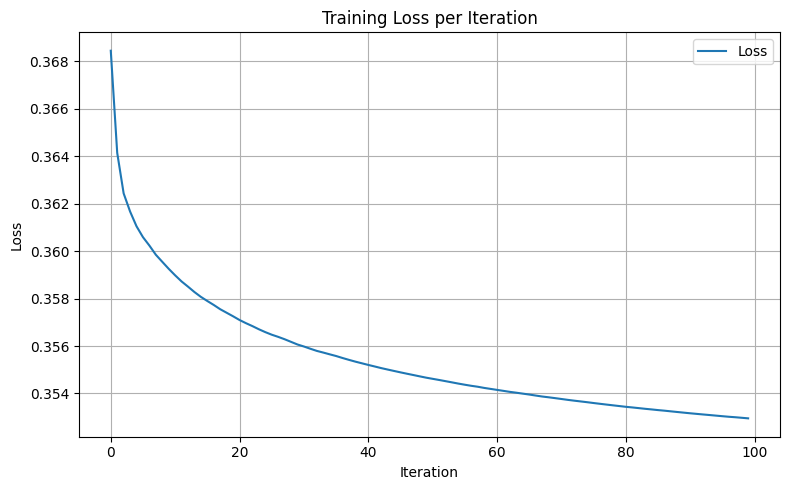

In [9]:
model = SQBC()
model.fit(X_train_01, y_train_01)
model.plot_loss()

In [92]:
model = SQBC()
best_t, best_score = optimize_threshold_sqbc(model, X_train_01, y_train_01)
print("Best threshold t: ", best_t)
print("Best score: ", best_score)

Fold 1/5
Fold 2/5
Fold 3/5
Fold 4/5
Fold 5/5
Best threshold t:  -0.09026969871498591
Best score:  0.7882946395024356


### Classification evaluation

In [10]:
# Define personnalized metrics 
 
def specificity_score(y_true, y_pred):
    """
    Computes specificity of classification.

    Parameters: 
        y_true (np.array): true value of target variable
        y_pred (np.array): predicted value of target  variable

    Returns:
    float: specificity score
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    return specificity


def weighted_accuracy_score(y_true, y_pred):
    """
    Computes weighted accuracy according to proportion of positive examples p.

    Parameters: 
        y_true (np.array): true value of target variable
        y_pred (np.array): predicted value of target  variable

    Returuns:
        float: weighted accuracy 
    """
    
    acc_pos = recall_score(y_true, y_pred, zero_division=0) 
    acc_neg = specificity_score(y_true, y_pred)

    p = np.mean(y_true)
    weighted_acc = p * acc_pos + (1 - p) * acc_neg

    return weighted_acc


def cost_score(y_true, y_pred, cost_10=10, cost_01=100, cost_11=10, cost_00=0, normalize=True):
    """
    Computes total cost of classification based on cost matrix.
    Return:
        float: opposite of total coast
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp*cost_10 + fn*cost_01 + tp*cost_11 + tn*cost_00

    if normalize==True:
        FP = (y_true == 0).sum()
        FN = (y_true == 1).sum()
        max_cost = FP*cost_10 + FN*cost_01 
        total_cost = total_cost / max_cost if max_cost > 0 else 0.0
        
    return -total_cost

In [11]:
def evaluate(y_true, y_pred, cost_10=10, cost_01=100, cost_11=10, cost_00=0, plot=True):
    """
    Returns and plots classification results.

    Parameters: 
        y_true (np.array): true value of target variable
        y_pred (np.array): predicted value of target  variable

    Returns:
        dictionary: evaluation metrics
    """  
    acc = accuracy_score(y_true, y_pred)
    w_acc = balanced_accuracy_score(y_true, y_pred) # harmonic mean of recall and specificty
    rec = recall_score(y_true, y_pred, zero_division=0) 
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = specificity_score(y_true, y_pred)
    cost = -cost_score(y_true, y_pred, 
                        cost_10=cost_10, cost_01=cost_01, 
                        cost_11=cost_11, cost_00=cost_00
                    )

    metrics = {
            "F1-score": round(f1, 3),
            "Accuracy": round(acc, 3),
            "Balanced Accuracy": round(w_acc, 3),
            "Recall": round(rec, 3),
            "Precision": round(prec, 3),
            "Specificity": round(spec, 3),
            "Cost": round(cost, 3)
        }
    
    if plot:
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot()
        plt.show()

        print(metrics)
    
    return metrics 

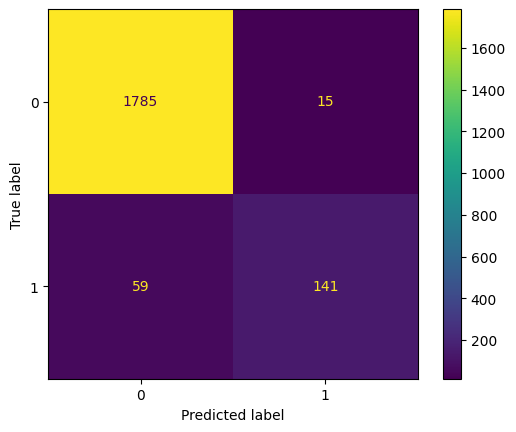

{'F1-score': 0.792, 'Accuracy': 0.963, 'Balanced Accuracy': 0.848, 'Recall': 0.705, 'Precision': 0.904, 'Specificity': 0.992, 'Cost': 0.196}


In [12]:
y_pred_01 = model.predict(X_test_01)
metrics = evaluate(y_test_01, y_pred_01)

### State-of-art models

State of the art models are XGBoost algorithm with different loss functions, adpated to imbalance classification. They will all implement threshold optimization.

In [13]:
def train_eval_sota_model(X_train, y_train, X_test, y_test, base_model, score="f1"): 
    """
    Train state-of-the-art model with threshold optimization.
    """

    clf = TunedThresholdClassifierCV(
        estimator=base_model,
        scoring=score
    )

    # Entraînement
    clf.fit(X_train, y_train)

    # Prédiction directement avec le seuil optimal
    y_pred = clf.predict(X_test)

    metrics = evaluate(y_test, y_pred, plot=False)
    metrics["Threshold"] = round(clf.best_threshold_, 3)

    return metrics


In [14]:
def pipeline_sota(X_train, y_train, X_test, y_test, opt_metric="F1-score", score="f1",
                  models={
                      'XGBoost': xgb.XGBClassifier(),
                      'LightGBM': lgb.LGBMClassifier(),
                      'CatBoost': CatBoostClassifier(verbose=0),
                      'Random_Forest': RandomForestClassifier(),
                      'Logistic_Regression': LogisticRegression(max_iter=1000)
                  }):
    """
    Compares multiple XGBoost variants with thresholds optimized for a single metric.
    Displays a summary table of all metrics evaluated at that optimal threshold.
    """
    results = {}

    for name, base_model in models.items():
        print(f"\nTraining {name}")

        metrics = train_eval_sota_model(X_train, y_train, X_test, y_test, base_model, score="f1")
        results[name] = metrics


    # Summary of performance
    summary_df = pd.DataFrame(results).T.round(3)
    summary_df = summary_df.sort_values(by=opt_metric, ascending=(opt_metric=='Cost'))

    # Display with style 
    format_dict = {col: "{:.3f}" for col in summary_df.select_dtypes(include='number').columns}
    styled_df = (
        summary_df
        .style
        .format(format_dict)
        .set_table_styles([
            {'selector': f'th.col{i}', 'props': [('color', 'blue'), ('font-weight', 'bold')]} 
            for i, col in enumerate(summary_df.columns) if col==opt_metric
        ])
    )
    display(styled_df)

    return summary_df

In [15]:
res_soa_05 = pipeline_sota(X_train_05, y_train_05, X_test_05, y_test_05)
res_soa_01 = pipeline_sota(X_train_01, y_train_01, X_test_01, y_test_01)
res_soa_005 = pipeline_sota(X_train_005, y_train_005, X_test_005, y_test_005)
res_soa_002 = pipeline_sota(X_train_002, y_train_002, X_test_002, y_test_002)
res_soa_001 = pipeline_sota(X_train_001, y_train_001, X_test_001, y_test_001)


Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold
Logistic_Regression,0.997,0.998,0.998,0.997,0.998,0.998,0.094,0.505
CatBoost,0.973,0.973,0.973,0.977,0.969,0.969,0.113,0.475
XGBoost,0.964,0.965,0.964,0.956,0.973,0.973,0.129,0.576
LightGBM,0.956,0.957,0.956,0.942,0.970,0.971,0.141,0.566
Random_Forest,0.950,0.950,0.950,0.946,0.954,0.954,0.139,0.495



Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold
Logistic_Regression,0.990,0.998,0.992,0.985,0.995,0.999,0.060,0.465
CatBoost,0.922,0.985,0.956,0.920,0.925,0.992,0.094,0.394
XGBoost,0.909,0.982,0.946,0.900,0.918,0.991,0.104,0.384
LightGBM,0.894,0.979,0.946,0.905,0.883,0.987,0.104,0.374
Random_Forest,0.845,0.967,0.937,0.900,0.796,0.974,0.112,0.333



Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold
Logistic_Regression,0.990,0.999,0.995,0.990,0.990,0.999,0.038,0.444
CatBoost,0.910,0.991,0.953,0.910,0.910,0.995,0.066,0.303
XGBoost,0.886,0.989,0.942,0.890,0.881,0.994,0.073,0.253
LightGBM,0.863,0.987,0.922,0.850,0.876,0.994,0.085,0.263
Random_Forest,0.839,0.985,0.902,0.810,0.871,0.994,0.098,0.323



Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold
Logistic_Regression,0.951,0.998,0.987,0.975,0.929,0.998,0.022,0.404
XGBoost,0.810,0.992,0.922,0.850,0.773,0.995,0.044,0.152
LightGBM,0.769,0.990,0.933,0.875,0.686,0.992,0.043,0.040
CatBoost,0.740,0.991,0.836,0.675,0.818,0.997,0.069,0.343
Random_Forest,0.725,0.989,0.860,0.725,0.725,0.994,0.064,0.273



Training XGBoost

Training LightGBM

Training CatBoost

Training Random_Forest

Training Logistic_Regression


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold
Logistic_Regression,0.826,0.996,0.973,0.950,0.731,0.996,0.017,0.374
CatBoost,0.735,0.994,0.947,0.900,0.621,0.994,0.022,0.161
LightGBM,0.723,0.994,0.922,0.850,0.630,0.995,0.026,0.020
XGBoost,0.696,0.993,0.897,0.800,0.615,0.995,0.030,0.111
Random_Forest,0.542,0.989,0.821,0.650,0.464,0.992,0.045,0.207


In [16]:
def combine_results(pipeline_df, grid_metrics_dicts, model_names, opt_metric='F1-score'):
    """
    Combine SOA pipeline results with other results into a single summary DataFrame.
    Args:
        pipeline_df (pd.DataFrame): Output from pipeline_soa
        grid_metrics_dict (dict): List of dictionaries of output metrics
        model_name (str): List of model names
        opt_metric (str): Metric that was optimized (for sorting and highlighting)
    """
    combined_df = pipeline_df

    for i, dict in enumerate(grid_metrics_dicts):
        grid_df = pd.DataFrame([grid_metrics_dicts[i]], index=[f"{model_names[i]}"])
        combined_df = pd.concat([combined_df, grid_df], axis=0)

    # Display with style 
    combined_df = combined_df.sort_values(by=opt_metric, ascending=False if opt_metric != 'Cost' else True)

    format_dict = {col: "{:.3f}" for col in combined_df.select_dtypes(include='number').columns}
    styled_df = (
        combined_df
        .style
        .format(format_dict)
        .set_table_styles([
            {'selector': f'th.col{i}', 'props': [('color', 'blue'), ('font-weight', 'bold')]} 
            for i, col in enumerate(combined_df.columns) if col == opt_metric
        ])
    )
    display(styled_df)

    return #combined_df

## Optimal cost

Specific part for optimizing the cost metric. In that case, we know that the optimal threshold is: 
$$p^* = \frac{C(1,0) - C(0,0)}{C(1,0)-C(0,0)+C(0,1)-C(1,1)} = 1 - \tau.$$
Which yields an optimal $\tau$:
$$\tau^* = \frac{C(0,1)-C(1,1)}{C(1,0)-C(0,0)+C(0,1)-C(1,1)}.$$

In [88]:
def cost_vs_tau_plot_bootstrap(X, y, 
                     cost_10=10, cost_01=100, cost_11=10, cost_00=0,
                     tau_range=np.arange(0.01, 1, 0.05),
                     n_bootstrap=5, test_size=0.3,
                     n_estimators=100, alpha=0.01, 
                     eta=0.1, h=0.1, t=0, 
                     random_state=0, base_learner="tree"):
    """
    Bootstrap version: average total cost for each tau value over bootstrap samples.
    """
    all_costs = []

    for b in range(n_bootstrap):
        print(f"Bootstrap step {b+1}")
        
        X_boot, y_boot = resample(X, y)
        X_train, X_test, y_train, y_test = train_test_split(
            X_boot, y_boot, test_size=test_size, stratify=y_boot
            )

        costs = []
        for tau in tau_range:
            model = SQBC(
                        n_estimators=n_estimators, alpha=alpha, 
                        tau=tau, eta=eta, h=h, t=t, 
                        random_state=random_state, base_learner=base_learner
                    )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            cost = -cost_score(y_test, y_pred, cost_10, cost_01, cost_11, cost_00)
            costs.append(cost)
        all_costs.append(costs)

    all_costs = np.array(all_costs)
    avg_costs = np.mean(all_costs, axis=0)
    std_costs = np.std(all_costs, axis=0)
    print(tau_range)
    print(avg_costs - std_costs)
    print(avg_costs + std_costs)

    # Theoretical tau*
    p_star = (cost_10 - cost_00) / (cost_10 - cost_00 + cost_01 - cost_11)
    tau_star = 1 - p_star

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(tau_range, avg_costs, 'b-o', label='Avg Cost')
    if not np.allclose(avg_costs - std_costs, avg_costs + std_costs):
        plt.fill_between(
            tau_range,
            avg_costs - std_costs,
            avg_costs + std_costs,
            color='blue',
            alpha=0.2,
            label="±1 std"
            )
    plt.axvline(x=tau_star, color='red', linestyle='--', label=r'Theoretical $\tau^*$')
    plt.xlabel(r'Quantile level $\tau$')
    plt.ylabel('Total Cost')
    plt.title('Total Cost vs Threshold τ (with Bootstrap)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout(rect=[0, 0.05, 1, 1]) 
    plt.show()


In [89]:
cost_vs_tau_plot_bootstrap(X_05, y_05)

Bootstrap step 1


KeyboardInterrupt: 

Bootstrap step 1
Bootstrap step 2
Bootstrap step 3
Bootstrap step 4
Bootstrap step 5


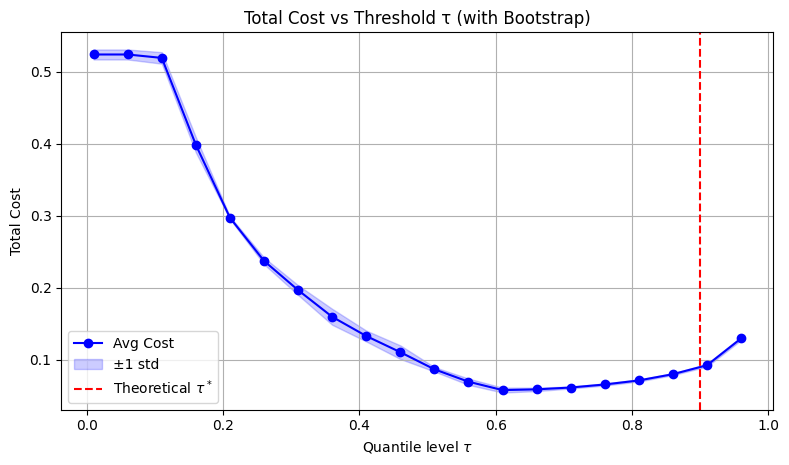

In [ ]:
cost_vs_tau_plot_bootstrap(X_01, y_01)

Divergence between theory and practice => to explain. The cost will therefore be optimized similarly to other metrics. 

## Effect of tau on metrics at different imbalance degrees

In [ ]:
# Range of values for tau and p 

p_range = [0.5, 0.2, 0.1, 0.05, 0.01]

tau_range = np.concatenate([
    np.linspace(0.1, 0.5, 3, endpoint=False),
    np.linspace(0.5, 0.7, 3, endpoint=False),
    np.linspace(0.7, 0.85, 5, endpoint=False),
    np.linspace(0.85, 0.99, 10, endpoint=False),
    np.linspace(0.99, 1, 10, endpoint=False)
])
print(len(tau_range))
print(tau_range)

31
[0.1        0.23333333 0.36666667 0.5        0.56666667 0.63333333
 0.7        0.73       0.76       0.79       0.82       0.85
 0.864      0.878      0.892      0.906      0.92       0.934
 0.948      0.962      0.976      0.99       0.991      0.992
 0.993      0.994      0.995      0.996      0.997      0.998
 0.999     ]


In [ ]:
def plot_metrics_vs_tau_for_imbalances(imbalances=p_range, tau_range=tau_range,
                                       nb_cols=2, 
                                       cost_10=10, cost_01=100, cost_11=10, cost_00=0):
    """
    For each imbalance level in `imbalances`, plot metric curves as a function of τ (with denser sampling after 0.5),
    and highlight the τ that minimizes cost.
    """
    metrics_names = ['Accuracy', 'Balanced Accuracy', 'Recall', 'Precision', 'Specificity', 'F1-score', 'Cost']
    n_imbalances = len(imbalances)

    # Prepare subplots
    total_plots = n_imbalances + 1 # one subplot for legend
    n_col = min(nb_cols, total_plots)
    n_row = total_plots//n_col + (total_plots%n_col > 0)

    fig, axes = plt.subplots(n_row, n_col, figsize=(15, 5*n_row), sharey=True)
    axes = axes.flatten()

    colors = plt.cm.get_cmap('tab10', len(metrics_names))

    for id, p in enumerate(imbalances):

        print('\nImbalance degree: ', p)

        X, y = generate_dataset(p=p)
        X_train, X_test, y_train, y_test = cross_val_set(X, y)

        metric_curves = {m: [] for m in metrics_names}

        for tau in tau_range:

            #print('Tau value: ', tau)

            # Fit model
            model = SQBC(tau=tau)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)

            # Retrieve metrics 
            metrics = evaluate(y_test, y_pred, cost_10, cost_01, cost_11, cost_00, plot=False)
            for m in metrics_names:
                metric_curves[m].append(metrics[m])

        # Plot metrics
        ax = axes[id]
        for i, m in enumerate(metrics_names):
            values = metric_curves[m]
            ax.plot(tau_range, values, linestyle='--', marker='o', markersize=4, color=colors(i), label=m)
            # Higlight best tau
            best_idx = np.argmin(values) if m=='Cost' else np.argmax(values)
            best_tau = tau_range[best_idx]
            ax.plot(best_tau, values[best_idx], marker='^', markersize=10, color=colors(i))

        ax.set_title(f"P(Y=1) = {p}")
        ax.set_xlabel(r"Quantile level $\tau$")
        if id % n_col == 0:
            ax.set_ylabel("Metric value")
        ax.grid(True)

    # Subplot for legend 
    legend_ax = axes[id+1]
    legend_ax.axis('off') 
    handles, labels = axes[0].get_legend_handles_labels()
    legend_ax.legend(handles, labels, loc='upper center', fontsize=12, ncol=2, frameon=False)

    # Delete empty plots
    for j in range(n_imbalances+1, n_row * n_col):
        fig.delaxes(axes[j])

    plt.suptitle("Metric evolution according to τ with best τ per metric (▲)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


Imbalance degree:  0.5

Imbalance degree:  0.2

Imbalance degree:  0.1

Imbalance degree:  0.05

Imbalance degree:  0.01


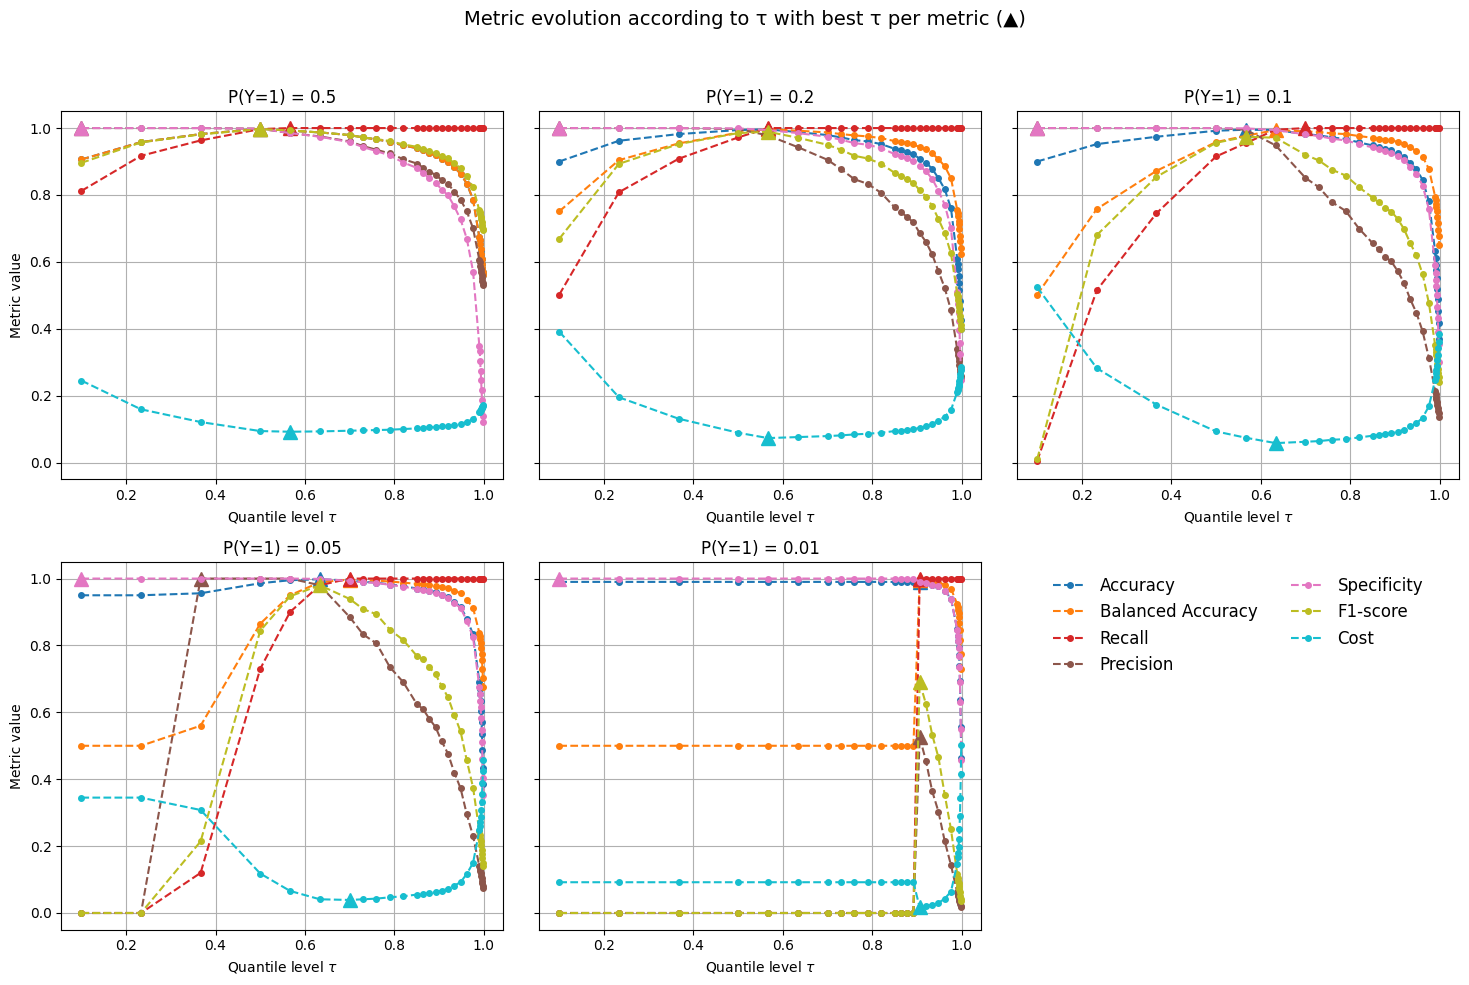

In [ ]:
#plot_metrics_vs_tau_for_imbalances(nb_cols=3)


Imbalance degree:  0.5

Imbalance degree:  0.2

Imbalance degree:  0.1

Imbalance degree:  0.05

Imbalance degree:  0.01


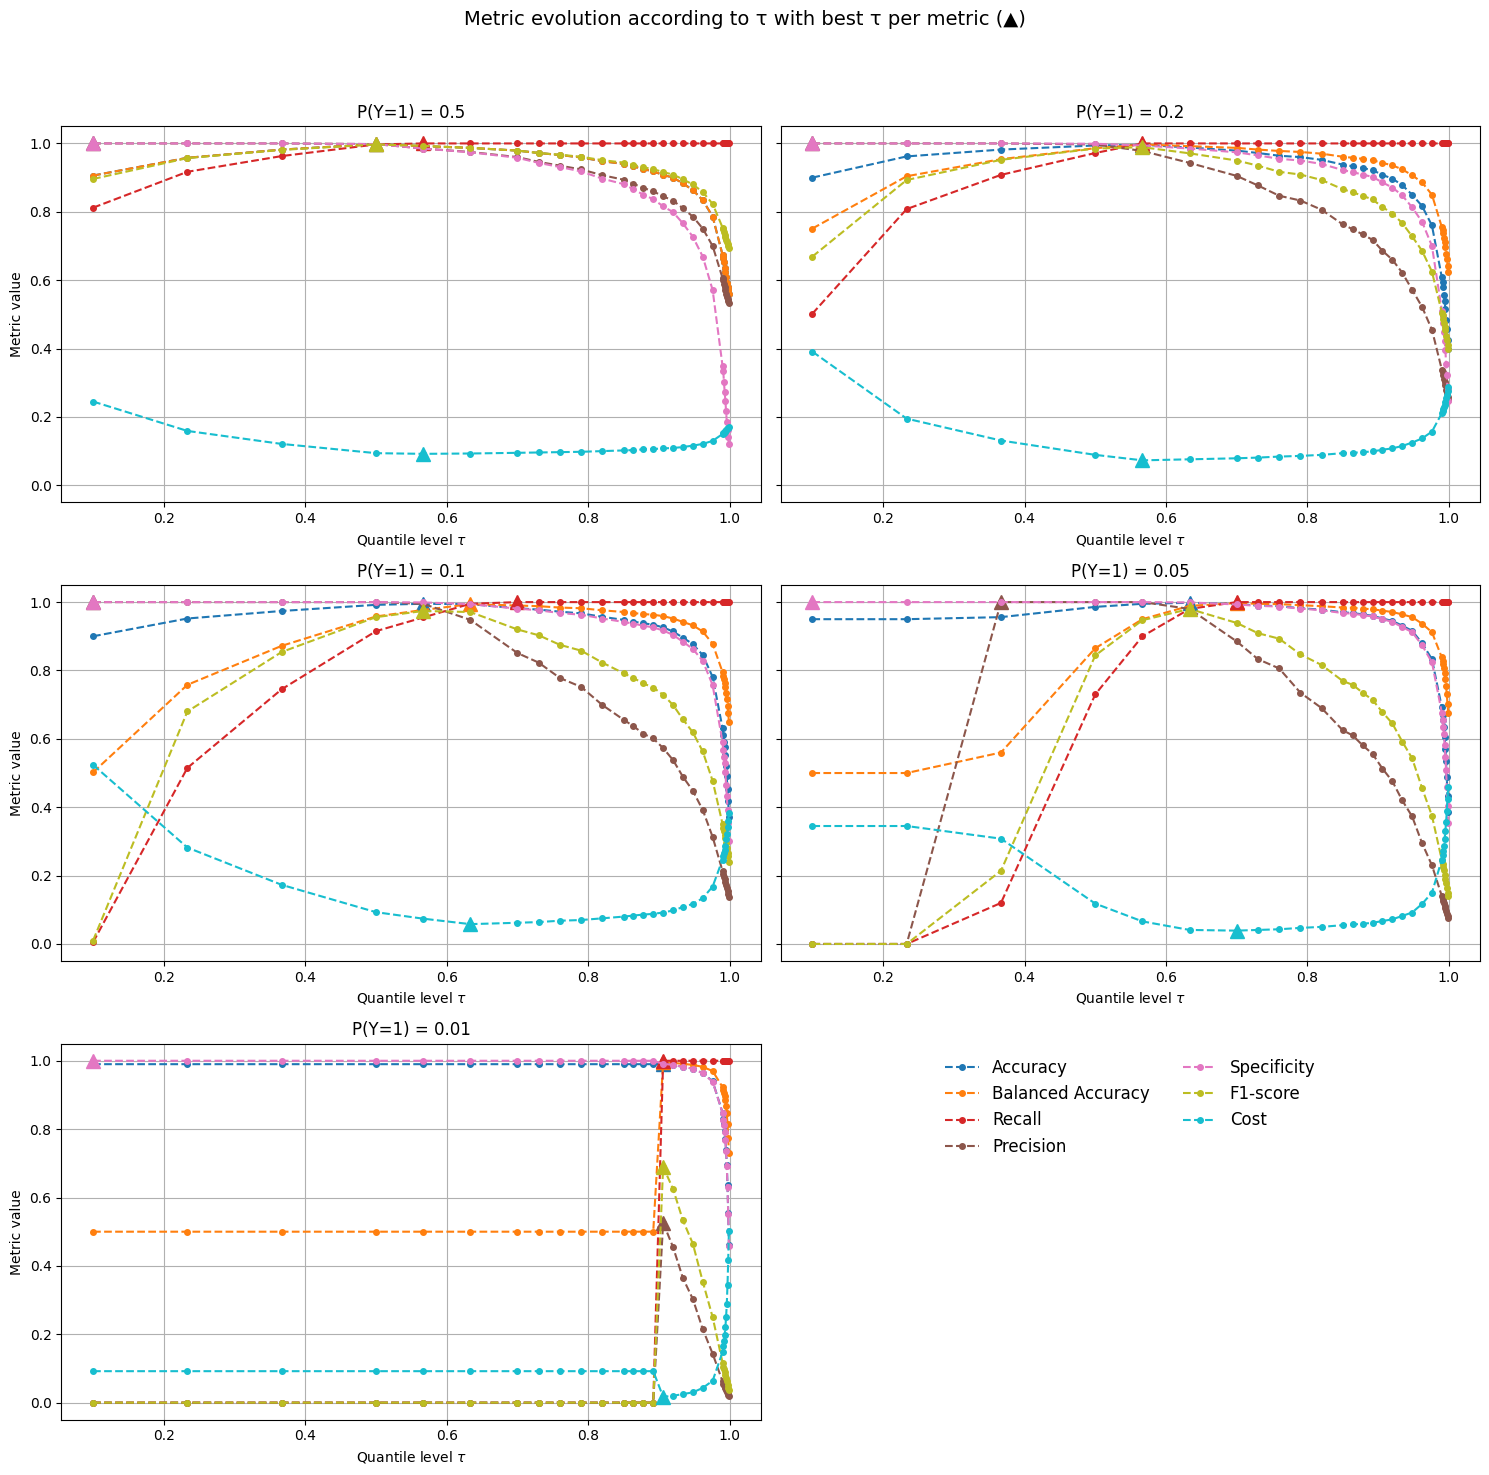

In [ ]:
plot_metrics_vs_tau_for_imbalances()

## Hyperparameter tuning: varying $\tau$

##### **Threshold adjustment: varying t**

In [3]:
def threshold_adjustment(X_train, y_train, X_test, y_test,
                        n_estimators=100, alpha=0.01, 
                        tau=0.5, eta=0.1, h=0.1, t=0, 
                        random_state=0, base_learner="tree"):

    model = SQBC( 
            n_estimators=n_estimators, 
            alpha=alpha, tau=tau, eta=eta, 
            h=h, t=t, random_state=random_state,
            base_learner=base_learner
        ) 

    best_t, _ = optimize_threshold_sqbc(model, X_train, y_train)
    y_pred = model.predict(X_test)
    metrics = evaluate(y_test, y_pred, plot=False)
    metrics['Threshold'] = best_t

    return metrics 

##### **Grid search and interpolation**

In [ ]:
def grid_search_tau_interpolated(X, y, X_test, y_test,
                                tau_range=np.linspace(0.01, 0.99, 10),
                                cost_10=10, cost_01=100, cost_11=10, cost_00=0,
                                n_splits=3, resolution=200,
                                opt_metric="F1-score", interpolation=True,
                                n_estimators=100, alpha=0.01, 
                                eta=0.1, h=0.1, t=0, 
                                random_state=0, base_learner="tree",
                                model_type="SQBC", score="f1"):
    """
    Grid search over tau (with optional interpolation) to find the tau that optimizes opt_metric.
    """
    metric_names = ['F1-score', 'Accuracy', 'Balanced Accuracy', 'Recall', 'Precision', 'Specificity', 'Cost']
    if opt_metric not in metric_names:
            raise ValueError("Invalid metric name")

    metric_curves = {m: np.zeros(len(tau_range)) for m in metric_names}
    metrics_at_best2 = None

    folds = cross_val_set(X, y, mode='kfold', n_splits=n_splits)
    for fold_id, (X_train, X_val, y_train, y_val) in enumerate(folds):
        
        print(f"Fold {fold_id + 1}/{n_splits}")

        for i, tau in enumerate(tau_range):
            #print('Tau value: ', tau)

            # Fit model

            if model_type=="SQBC":
                model = SQBC(
                            n_estimators=n_estimators, alpha=alpha, 
                            tau=tau, eta=eta, h=h, t=t, 
                            random_state=random_state, base_learner=base_learner
                        )

            elif model_type=="XGB":
                 model = XGBSQBC(tau=tau, alpha=alpha, h=h)

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
                 
            # Retrieve metrics
            metrics = evaluate(y_val, y_pred, cost_10, cost_01, cost_11, cost_00, plot=False)
            for m in metric_curves:
                metric_curves[m][i] += metrics[m] / n_splits  # average over folds
        

    if interpolation: 
        interpolator = interp1d(tau_range, metric_curves[opt_metric])
        fine_taus = np.linspace(tau_range.min(), tau_range.max(), resolution)
        fine_metrics = interpolator(fine_taus)

        best_idx = np.argmin(fine_metrics) if opt_metric=='Cost' else np.argmax(fine_metrics)
        best_tau = fine_taus[best_idx]

        
    else: 
        best_idx = np.argmin(metric_curves[opt_metric]) if opt_metric == 'Cost' else np.argmax(metric_curves[opt_metric])
        best_tau = tau_range[best_idx]
    
    # Model with best tau

    if model_type=="SQBC":
        model = SQBC(
                        n_estimators=n_estimators, alpha=alpha, 
                        tau=best_tau, eta=eta, h=h, t=t, 
                        random_state=random_state, base_learner=base_learner
                    )
        model.fit(X, y)
        y_pred = model.predict(X_test)
        metrics_at_best = evaluate(y_test, y_pred, cost_10, cost_01, cost_11, cost_00, plot=False)

        # Model with best tau and threshold adjustment 
        metrics_at_best2 = threshold_adjustment(X, y, X_test, y_test, tau=best_tau)

    elif model_type=="XGB":
        model = XGBSQBC(tau=tau, alpha=alpha, h=h)
        clf = TunedThresholdClassifierCV(
            estimator=model,
            scoring=score
        )
        clf.fit(X, y)
        y_pred = clf.predict(X_test)

        metrics_at_best = evaluate(y_test, y_pred, plot=False)
        metrics_at_best["Threshold"] = round(clf.best_threshold_, 3)
         
    else:
        raise ValueError("model should be 'SQBC' or 'XGB'")
    
    metrics_at_best["Level_tau"] = best_tau

    return metrics_at_best, metrics_at_best2

In [ ]:
grid_sqbc_metrics_05, t_sqbc_metrics_05 = grid_search_tau_interpolated(X_train_05, y_train_05, X_test_05, y_test_05)
grid_sqbc_metrics_01, t_sqbc_metrics_01 = grid_search_tau_interpolated(X_train_01, y_train_01, X_test_01, y_test_01)
grid_sqbc_metrics_005, t_sqbc_metrics_005 = grid_search_tau_interpolated(X_train_005, y_train_005, X_test_005, y_test_005)
grid_sqbc_metrics_002, t_sqbc_metrics_002 = grid_search_tau_interpolated(X_train_002, y_train_002, X_test_002, y_test_002)
grid_sqbc_metrics_001, t_sqbc_metrics_001 = grid_search_tau_interpolated(X_train_001, y_train_001, X_test_001, y_test_001)

In [110]:
combine_results(res_soa_05, [t_sqbc_metrics_05, grid_sqbc_metrics_05],
                            model_names=["SQBC_threshold", "SQBC_grid_search"])
combine_results(res_soa_01, [t_sqbc_metrics_01, grid_sqbc_metrics_01],
                            model_names=["SQBC_threshold", "SQBC_grid_search"])
combine_results(res_soa_005, [t_sqbc_metrics_005, grid_sqbc_metrics_005],
                            model_names=["SQBC_threshold", "SQBC_grid_search"])
combine_results(res_soa_002, [t_sqbc_metrics_002, grid_sqbc_metrics_002],
                            model_names=["SQBC_threshold", "SQBC_grid_search"])
combine_results(res_soa_001, [t_sqbc_metrics_001, grid_sqbc_metrics_001],
                            model_names=["SQBC_threshold", "SQBC_grid_search"])

,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.997,0.998,0.998,0.997,0.998,0.998,0.094,0.505,nan
CatBoost,0.973,0.973,0.973,0.977,0.969,0.969,0.113,0.475,nan
XGBoost,0.964,0.965,0.964,0.956,0.973,0.973,0.129,0.576,nan
LightGBM,0.956,0.957,0.956,0.942,0.970,0.971,0.141,0.566,nan
Random_Forest,0.947,0.948,0.948,0.942,0.952,0.953,0.143,0.505,nan
SQBC_grid_search,0.939,0.938,0.938,0.948,0.929,0.928,0.140,nan,0.557
SQBC_threshold,0.376,0.615,0.615,0.232,0.991,0.998,0.719,-0.090,nan


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.990,0.998,0.992,0.985,0.995,0.999,0.060,0.465,nan
CatBoost,0.922,0.985,0.956,0.920,0.925,0.992,0.094,0.394,nan
XGBoost,0.909,0.982,0.946,0.900,0.918,0.991,0.104,0.384,nan
LightGBM,0.894,0.979,0.946,0.905,0.883,0.987,0.104,0.374,nan
Random_Forest,0.848,0.969,0.923,0.865,0.832,0.981,0.126,0.364,nan
SQBC_grid_search,0.784,0.954,0.901,0.835,0.739,0.967,0.146,nan,0.660
SQBC_threshold,0.691,0.932,0.856,0.760,0.633,0.951,0.189,-0.090,nan


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.990,0.999,0.995,0.990,0.990,0.999,0.038,0.444,nan
CatBoost,0.910,0.991,0.953,0.910,0.910,0.995,0.066,0.303,nan
XGBoost,0.886,0.989,0.942,0.890,0.881,0.994,0.073,0.253,nan
LightGBM,0.863,0.987,0.922,0.850,0.876,0.994,0.085,0.263,nan
Random_Forest,0.827,0.982,0.924,0.860,0.796,0.988,0.086,0.287,nan
SQBC_threshold,0.596,0.935,0.947,0.960,0.432,0.934,0.090,-0.090,nan
SQBC_grid_search,0.559,0.961,0.742,0.500,0.633,0.985,0.200,nan,0.665


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.951,0.998,0.987,0.975,0.929,0.998,0.022,0.404,nan
XGBoost,0.810,0.992,0.922,0.850,0.773,0.995,0.044,0.152,nan
LightGBM,0.769,0.990,0.933,0.875,0.686,0.992,0.043,0.040,nan
Random_Forest,0.741,0.990,0.872,0.750,0.732,0.994,0.060,0.261,nan
CatBoost,0.740,0.991,0.836,0.675,0.818,0.997,0.069,0.343,nan
SQBC_grid_search,0.342,0.975,0.657,0.325,0.361,0.988,0.130,nan,0.773
SQBC_threshold,0.290,0.902,0.950,1.000,0.169,0.900,0.100,-0.090,nan


,F1-score,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,Cost,Threshold,Level_tau
Logistic_Regression,0.826,0.996,0.973,0.950,0.731,0.996,0.017,0.374,nan
CatBoost,0.735,0.994,0.947,0.900,0.621,0.994,0.022,0.161,nan
LightGBM,0.723,0.994,0.922,0.850,0.630,0.995,0.026,0.020,nan
XGBoost,0.696,0.993,0.897,0.800,0.615,0.995,0.030,0.111,nan
Random_Forest,0.528,0.988,0.845,0.700,0.424,0.990,0.043,0.172,nan
SQBC_grid_search,0.214,0.978,0.642,0.300,0.167,0.985,0.081,nan,0.882
SQBC_threshold,0.154,0.890,0.945,1.000,0.084,0.889,0.110,-0.090,nan


## XGBoost with SQBC loss

In [19]:
# XGBoost with SQBC loss

def sqbc_like_loss(tau=0.5, alpha=0.01, h=0.1):
    """
    SQBC-inspired loss function for XGBoost.
    """

    def sqbc_obj(y_pred, dtrain):

        y_true = dtrain.get_label()
        f = y_pred  # raw score / logit

        Kf = norm.cdf(f/h)
        K_prime_f = norm.pdf(f/h)
        K_sec_f = -f/h**3 * norm.pdf(f/h)
        exp_term = np.exp((y_true - Kf)/alpha)

        grad = -K_prime_f * (tau - 1 / (1 + exp_term))
        #hess = -K_sec_f * (tau - 1 / (1 + exp_term)) + K_prime_f**2 * exp_term/(1+exp_term)**2 / alpha
        #hess = np.clip(hess, 1e-3, 1.0)

        hess = np.ones_like(grad) * 0.1
        

        return grad, hess

    return sqbc_obj

In [27]:
class XGBSQBC(BaseEstimator):
    """XGBoost classifier with SQBC-like custom loss."""

    _estimator_type = "classifier"

    def __init__(self, tau=0.5, alpha=0.5, h=0.1,
                 max_depth=3, eta=0.1, n_estimators=100, random_state=0):
        self.tau = tau
        self.alpha = alpha
        self.h = h
        self.max_depth = max_depth
        self.eta = eta
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        
        dtrain = xgb.DMatrix(X, label=y)
        params = {
            "objective": 'binary:logistic',
            "max_depth": self.max_depth,
            "eta": self.eta,
            "verbosity": 0,
            "seed": self.random_state
        }
        self.bst_ = xgb.train(
            params, dtrain, num_boost_round=self.n_estimators,
            obj=sqbc_like_loss(self.tau, self.alpha, self.h)
        )
        return self

    def predict_proba(self, X):
        dtest = xgb.DMatrix(X)
        y_proba = self.bst_.predict(dtest)
        return np.column_stack((1 - y_proba, y_proba))

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)


In [30]:
def train_eval_xgb_sqbc(X_train, y_train, X_test, y_test, tau=0.5, alpha=0.5, h=0.1, score="f1"):
  
    model = XGBSQBC(tau=tau, alpha=alpha, h=h)

    clf = TunedThresholdClassifierCV(
        estimator=model,
        scoring=score
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    metrics = evaluate(y_test, y_pred, plot=False)
    metrics["Threshold"] = round(clf.best_threshold_, 3)
    metrics["Level_tau"] = tau
    print(metrics)

    return metrics 

In [29]:
xgb_sqbc_metrics_05 = train_eval_xgb_sqbc(X_train_05, y_train_05, X_test_05, y_test_05)
xgb_sqbc_metrics_01 = train_eval_xgb_sqbc(X_train_01, y_train_01, X_test_01, y_test_01)
xgb_sqbc_metrics_005 = train_eval_xgb_sqbc(X_train_005, y_train_005, X_test_05, y_test_005)
xgb_sqbc_metrics_002 = train_eval_xgb_sqbc(X_train_002, y_train_002, X_test_002, y_test_002)
xgb_sqbc_metrics_001 = train_eval_xgb_sqbc(X_train_001, y_train_001, X_test_001, y_test_001)

{'F1-score': 0.963, 'Accuracy': 0.963, 'Balanced Accuracy': 0.962, 'Recall': 0.973, 'Precision': 0.953, 'Specificity': 0.952, 'Cost': 0.117, 'Threshold': 0.497}
{'F1-score': 0.883, 'Accuracy': 0.977, 'Balanced Accuracy': 0.927, 'Recall': 0.865, 'Precision': 0.901, 'Specificity': 0.989, 'Cost': 0.122, 'Threshold': 0.497}
{'F1-score': 0.067, 'Accuracy': 0.902, 'Balanced Accuracy': 0.508, 'Recall': 0.07, 'Precision': 0.064, 'Specificity': 0.946, 'Cost': 0.358, 'Threshold': 0.488}
{'F1-score': 0.785, 'Accuracy': 0.992, 'Balanced Accuracy': 0.885, 'Recall': 0.775, 'Precision': 0.795, 'Specificity': 0.996, 'Cost': 0.055, 'Threshold': 0.49}
{'F1-score': 0.625, 'Accuracy': 0.991, 'Balanced Accuracy': 0.872, 'Recall': 0.75, 'Precision': 0.536, 'Specificity': 0.993, 'Cost': 0.036, 'Threshold': 0.483}


## Combined results

In [967]:
combine_results(res_soa_05, [sqbc_metrics_05, xgb_sqbc_metrics_05],
                            model_names=["SQBC_grid_search", "XGB_SQBC_like"])
combine_results(res_soa_01, [sqbc_metrics_01, xgb_sqbc_metrics_01],
                            model_names=["SQBC_grid_search", "XGB_SQBC_like"])
combine_results(res_soa_005, [sqbc_metrics_005, xgb_sqbc_metrics_005],
                            model_names=["SQBC_grid_search", "XGB_SQBC_like"])
combine_results(res_soa_002, [sqbc_metrics_002, xgb_sqbc_metrics_002],
                            model_names=["SQBC_grid_search", "XGB_SQBC_like"])
combine_results(res_soa_001, [sqbc_metrics_001, xgb_sqbc_metrics_001],
                            model_names=["SQBC_grid_search", "XGB_SQBC_like"])

,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,F1-score,Cost,Threshold
Logistic_Regression,0.997,0.997,0.998,0.997,0.997,0.997,0.093,0.505
SQBC_grid_search,0.995,0.995,0.998,0.992,0.992,0.995,0.094,0.512
XGB_SQBC_like,0.995,0.995,1.000,0.990,0.990,0.995,0.092,0.497
CatBoost,0.969,0.969,0.975,0.963,0.963,0.969,0.115,0.465
XGBoost,0.948,0.948,0.954,0.943,0.942,0.949,0.133,0.459
LightGBM,0.944,0.945,0.958,0.933,0.931,0.946,0.131,0.449
Random_Forest,0.921,0.921,0.940,0.907,0.903,0.923,0.149,0.465


,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,F1-score,Cost,Threshold
Logistic_Regression,0.999,0.995,0.990,0.995,0.999,0.993,0.058,0.452
SQBC_grid_search,0.997,0.992,0.985,0.988,0.999,0.986,0.060,0.576
XGB_SQBC_like,0.995,0.995,0.995,0.957,0.995,0.975,0.057,0.514
CatBoost,0.980,0.935,0.879,0.920,0.991,0.899,0.114,0.373
XGBoost,0.973,0.919,0.852,0.877,0.986,0.863,0.129,0.291
LightGBM,0.970,0.924,0.866,0.837,0.981,0.851,0.125,0.254
Random_Forest,0.960,0.888,0.798,0.800,0.978,0.799,0.159,0.337


,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,F1-score,Cost,Threshold
Logistic_Regression,0.998,0.995,0.992,0.971,0.998,0.981,0.038,0.399
XGB_SQBC_like,0.998,0.989,0.980,0.970,0.998,0.975,0.042,0.513
SQBC_grid_search,0.996,0.995,0.994,0.938,0.997,0.965,0.039,0.655
CatBoost,0.985,0.929,0.866,0.842,0.991,0.853,0.082,0.248
XGBoost,0.983,0.905,0.818,0.832,0.991,0.825,0.097,0.198
LightGBM,0.981,0.903,0.816,0.818,0.990,0.813,0.098,0.198
Random_Forest,0.974,0.861,0.734,0.750,0.987,0.741,0.126,0.300


,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,F1-score,Cost,Threshold
XGB_SQBC_like,1.000,0.988,0.975,1.000,1.000,0.987,0.021,0.506
Logistic_Regression,0.999,0.990,0.980,0.985,1.000,0.982,0.021,0.380
SQBC_grid_search,0.996,0.998,1.000,0.838,0.996,0.912,0.020,0.803
CatBoost,0.992,0.907,0.820,0.794,0.995,0.798,0.049,0.162
XGBoost,0.990,0.894,0.795,0.729,0.994,0.760,0.053,0.072
LightGBM,0.990,0.850,0.705,0.781,0.996,0.736,0.066,0.102
Random_Forest,0.987,0.810,0.626,0.681,0.994,0.649,0.079,0.267


,Accuracy,Balanced Accuracy,Recall,Precision,Specificity,F1-score,Cost,Threshold
Logistic_Regression,0.999,0.995,0.990,0.962,0.999,0.976,0.010,0.369
XGB_SQBC_like,0.997,0.924,0.850,0.850,0.998,0.850,0.023,0.449
LightGBM,0.994,0.898,0.800,0.672,0.996,0.730,0.029,0.017
CatBoost,0.994,0.878,0.759,0.691,0.996,0.716,0.032,0.135
XGBoost,0.995,0.819,0.639,0.804,0.998,0.707,0.041,0.208
Random_Forest,0.990,0.812,0.632,0.487,0.993,0.548,0.045,0.201
SQBC_grid_search,0.830,0.914,1.000,0.055,0.829,0.105,0.165,0.990


## Learning $\tau$

## Test

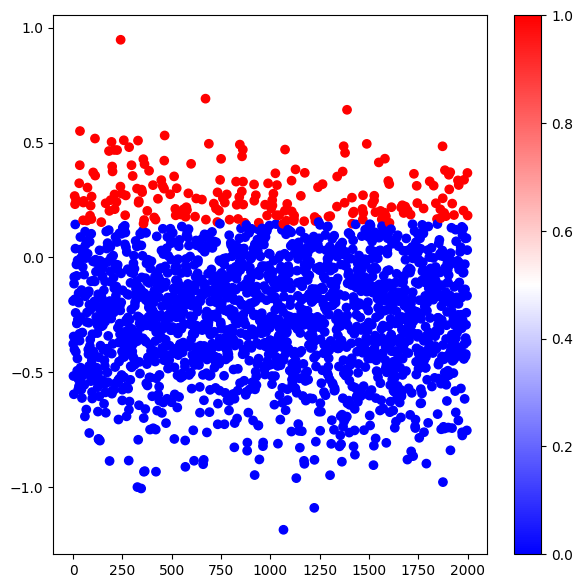

In [962]:
tau = 0.95
model_sqbc = SQBC(tau=tau)
model_sqbc.fit(X_train_01, y_train_01)
y_pred_sqbc = model_sqbc.predict_quantile(X_test_01)

plt.figure(figsize=(7, 7))
plt.scatter(range(len(y_pred_sqbc)), y_pred_sqbc, c=y_test_01, cmap='bwr')  
plt.colorbar()  
plt.show()


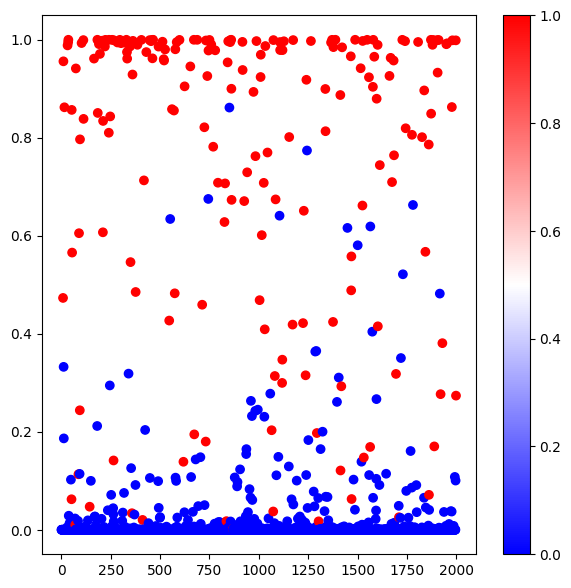

In [ ]:
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train_01, y_train_01)
y_pred_xgb = model_xgb.predict_proba(X_test_01)[:,1]

plt.figure(figsize=(7, 7))
plt.scatter(range(len(y_pred_xgb)), y_pred_xgb, c=y_test, cmap='bwr')  
plt.colorbar()  
plt.show()

In [ ]:
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict_proba(X_test)

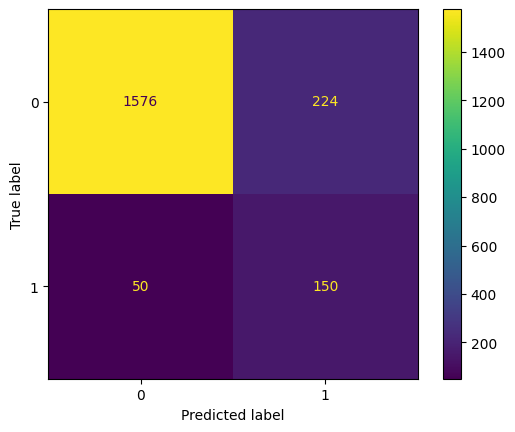

{'Accuracy': 0.863, 'Balanced Accuracy': 0.813, 'Recall': 0.75, 'Precision': 0.401, 'Specificity': 0.876, 'F1-score': 0.523, 'Cost': 0.23}
SQBC: {'Accuracy': 0.863, 'Balanced Accuracy': 0.813, 'Recall': 0.75, 'Precision': 0.401, 'Specificity': 0.876, 'F1-score': 0.523, 'Cost': 0.23}


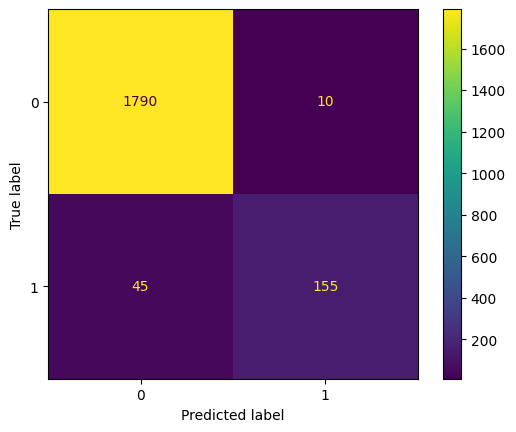

{'Accuracy': 0.972, 'Balanced Accuracy': 0.885, 'Recall': 0.775, 'Precision': 0.939, 'Specificity': 0.994, 'F1-score': 0.849, 'Cost': 0.162}
XGBoost: {'Accuracy': 0.972, 'Balanced Accuracy': 0.885, 'Recall': 0.775, 'Precision': 0.939, 'Specificity': 0.994, 'F1-score': 0.849, 'Cost': 0.162}


In [765]:
# Generate data
p = 0.1
X, y = generate_dataset(p=p)
X_train, X_test, y_train, y_test = cross_val_set(X, y)


# Fit models 

# SQBC tree
tau = 0.85
model_sqbc = SQBC(tau=tau)
model_sqbc.fit(X_train, y_train)
y_pred_sqbc = model_sqbc.predict(X_test)

# XGBoost
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print("SQBC:", evaluate(y_test, y_pred_sqbc))
print("XGBoost:", evaluate(y_test, y_pred_xgb))

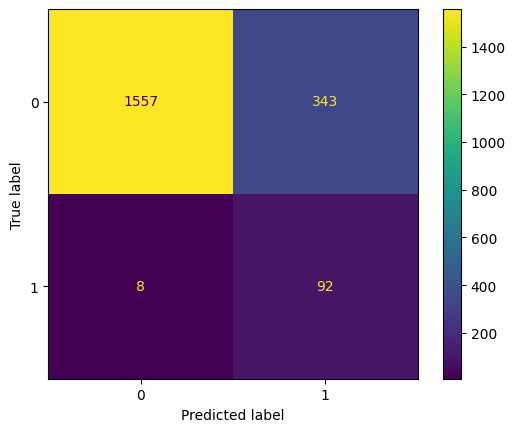

{'Accuracy': 0.824, 'Balanced Accuracy': 0.87, 'Recall': 0.92, 'Precision': 0.211, 'Specificity': 0.819, 'F1-score': 0.344, 'Cost': 0.178}
SQBC: {'Accuracy': 0.824, 'Balanced Accuracy': 0.87, 'Recall': 0.92, 'Precision': 0.211, 'Specificity': 0.819, 'F1-score': 0.344, 'Cost': 0.178}


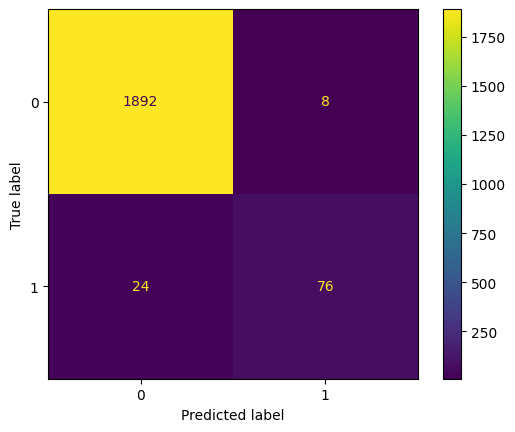

{'Accuracy': 0.984, 'Balanced Accuracy': 0.878, 'Recall': 0.76, 'Precision': 0.905, 'Specificity': 0.996, 'F1-score': 0.826, 'Cost': 0.112}
XGBoost: {'Accuracy': 0.984, 'Balanced Accuracy': 0.878, 'Recall': 0.76, 'Precision': 0.905, 'Specificity': 0.996, 'F1-score': 0.826, 'Cost': 0.112}


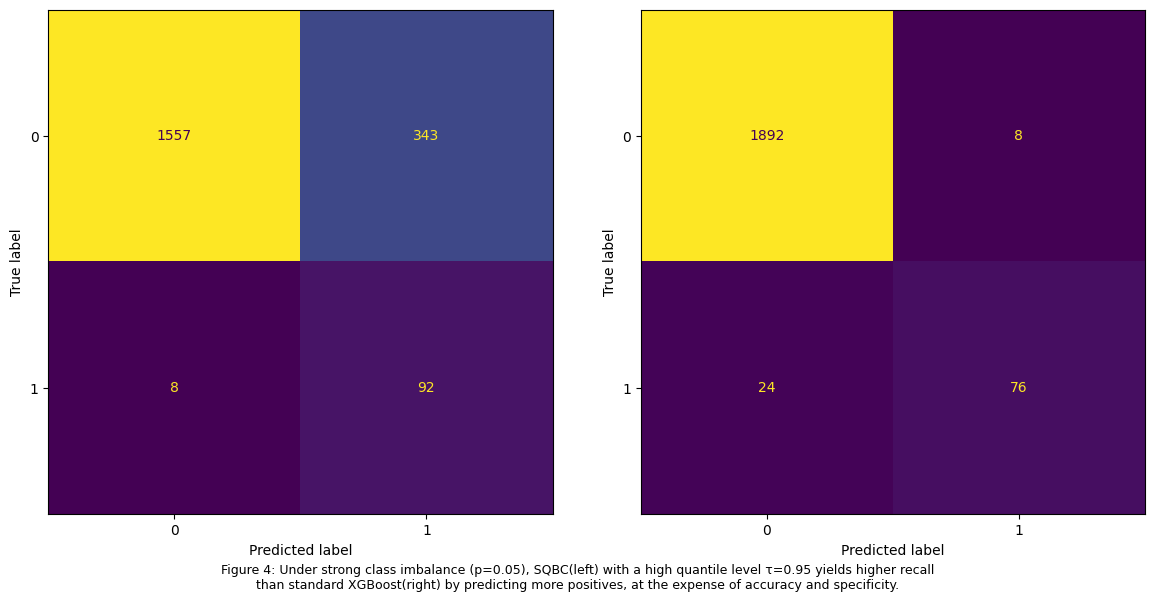

In [764]:
# Generate data
p = 0.05
X, y = generate_dataset(p=p)
X_train, X_test, y_train, y_test = cross_val_set(X, y)


# Fit models 

# SQBC tree
tau = 0.95
model_sqbc = SQBC(tau=tau)
model_sqbc.fit(X_train, y_train)
y_pred_sqbc = model_sqbc.predict(X_test)

# XGBoost
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)

print("SQBC:", evaluate(y_test, y_pred_sqbc))
print("XGBoost:", evaluate(y_test, y_pred_xgb))

# Plot confusion matrices 
cm_A = confusion_matrix(y_test, y_pred_sqbc, labels=[0, 1])
cm_B = confusion_matrix(y_test, y_pred_xgb, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

disp_A = ConfusionMatrixDisplay(confusion_matrix=cm_A, display_labels=[0, 1])
disp_A.plot(ax=axes[0], colorbar=False)

disp_B = ConfusionMatrixDisplay(confusion_matrix=cm_B, display_labels=[0, 1])
disp_B.plot(ax=axes[1], colorbar=False)

plt.tight_layout(rect=[0, 0.07, 1, 1]) 
plt.figtext(0.5, 0.01, f"Figure 4: Under strong class imbalance (p={p}), SQBC(left) with a high quantile level τ={tau} yields higher recall\n"
            "than standard XGBoost(right) by predicting more positives, at the expense of accuracy and specificity.", ha='center', fontsize=9)
plt.savefig("confusion_matrix.svg", format="svg")
plt.show()

## Estimate conditional variance

In [315]:
p = 0.5
X, y = generate_dataset(p=p)
X_train, X_test, y_train, y_test = cross_val_set(X, y)

In [330]:
# Assume you have q_low and q_high: predicted quantiles
tau_low, tau_high = 0.25, 0.75
z_low, z_high = norm.ppf(tau_low), norm.ppf(tau_high)

# Sample predictions
model_sqbc_low = SQBC(tau=tau_low)
model_sqbc_low.fit(X_train, y_train)
q_low = model_sqbc_low.predict_quantile(X_test)
model_sqbc_high = SQBC(tau=tau_high)
model_sqbc_high.fit(X_train, y_train)
q_high = model_sqbc_high.predict_quantile(X_test)

# Variance estimate
estimated_std = (q_high - q_low) / (z_high - z_low)
estimated_var = estimated_std**2


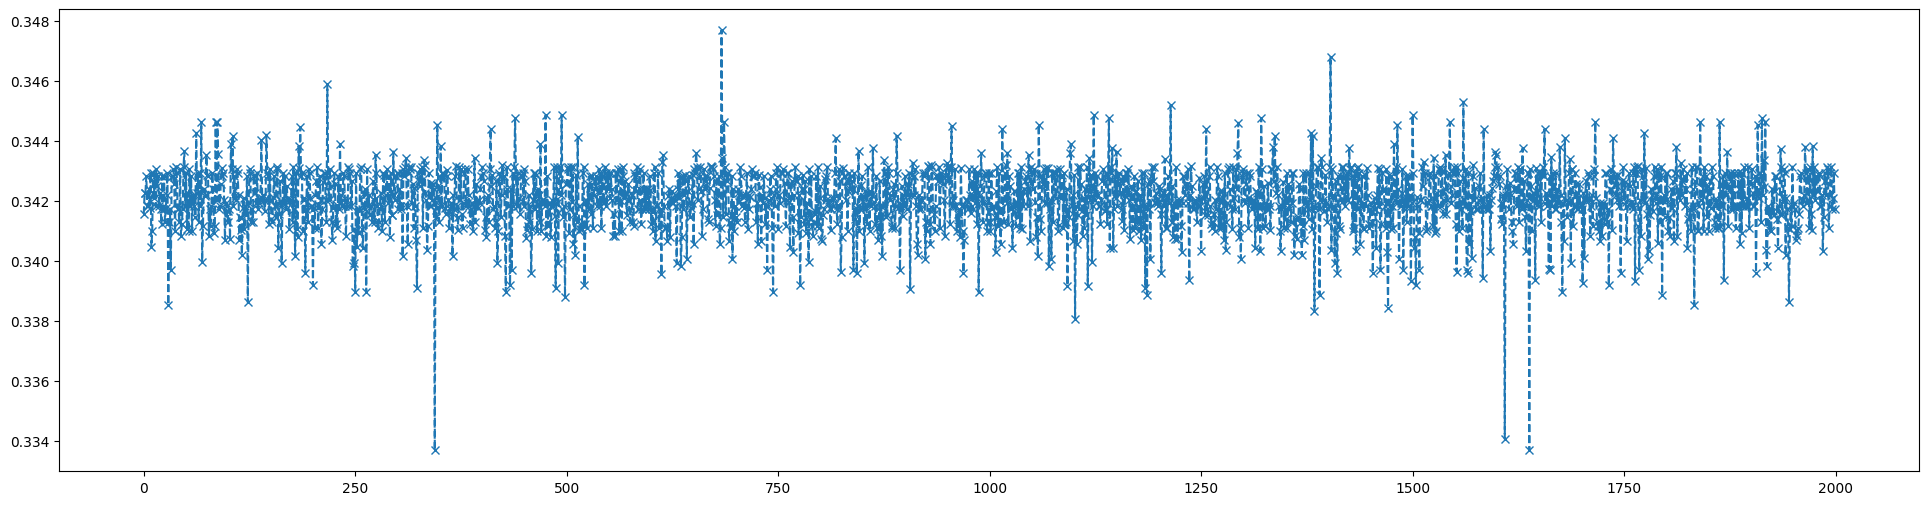

In [338]:
plt.figure(figsize=(24, 6))
plt.plot(estimated_std, 'x--')